In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import files

# Upload the file manually
uploaded = files.upload()

# Get the filename (first key in uploaded dict)
file_name = list(uploaded.keys())[0]

# Load the dataset
df = pd.read_csv(file_name)

# Display dataset info
print(df.info())
print(df.head())

# For better visuals
sns.set(style="whitegrid")

Saving train.csv to train.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0     

In [2]:
# Shape of the dataset
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")


# Statistical overview
df.describe(include='all')

Dataset contains 891 rows and 12 columns.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [3]:
# Checking missing values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


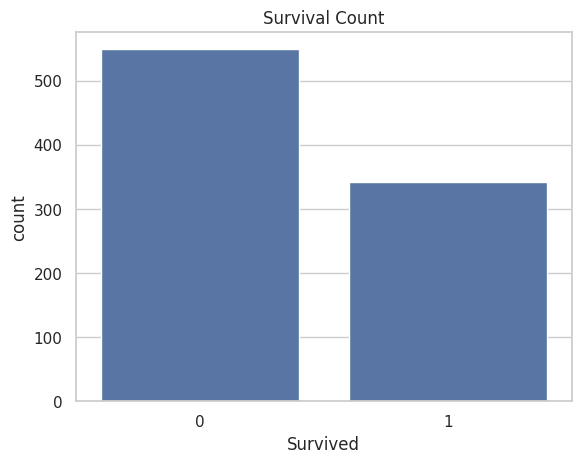

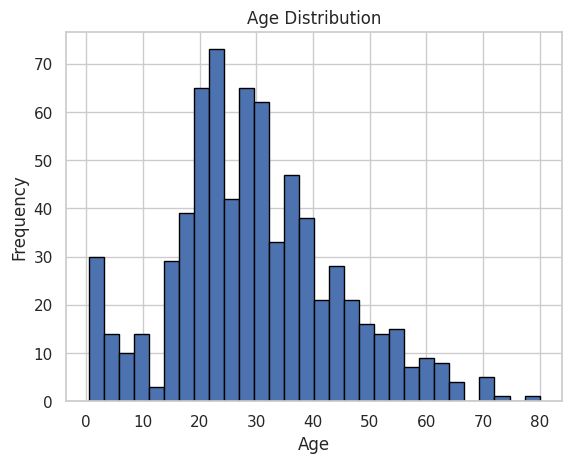

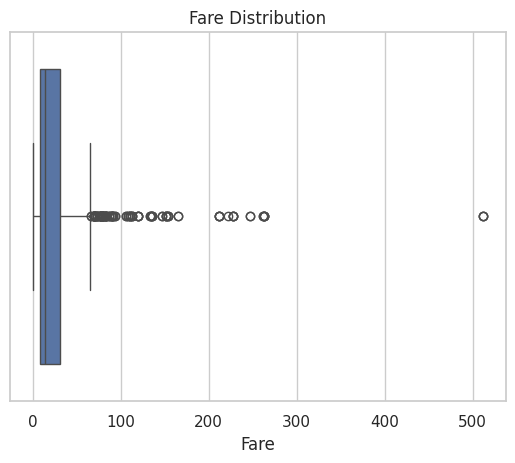

In [4]:
# Countplot for Survival
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.show()

# Distribution of Age
df['Age'].hist(bins=30, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Boxplot of Fare
sns.boxplot(x='Fare', data=df)
plt.title('Fare Distribution')
plt.show()


### Observation: Fare Distribution
- The majority of fares are clustered between **0 and 50**.
- There are several **outliers** with fares exceeding 200, possibly 1st class passengers.
- The fare distribution is **right-skewed**, indicating that most passengers paid lower fares.

### Observation: Age Distribution
- Most passengers were between **20 and 40 years old**.
- There is a noticeable concentration of passengers in their 20s and 30s.
- A few passengers were infants or elderly, showing a diverse age range.

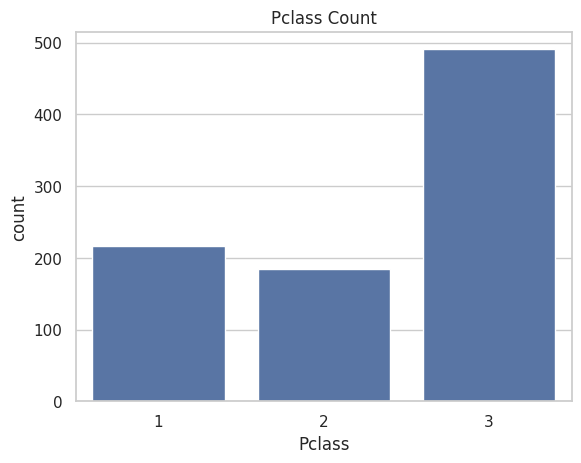

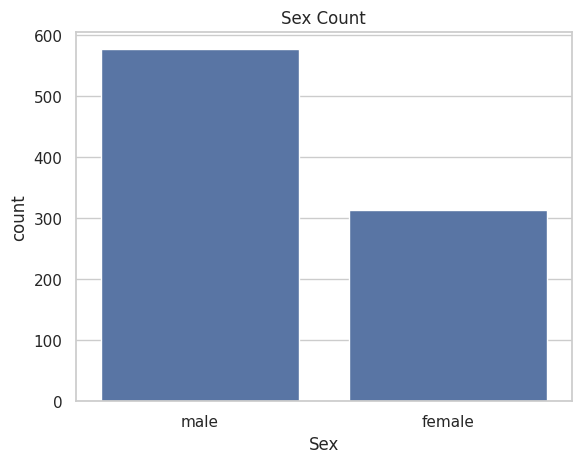

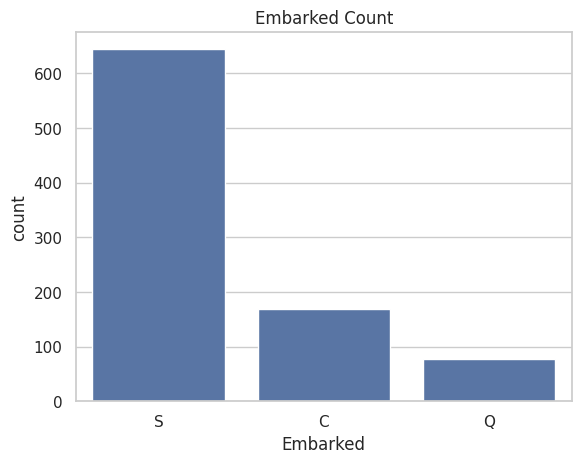

In [5]:
# Countplot for categorical variables
categorical_cols = ['Pclass', 'Sex', 'Embarked']

for col in categorical_cols:
    sns.countplot(x=col, data=df)
    plt.title(f'{col} Count')
    plt.show()

### Observation: Distribution of Categorical Features

- **Pclass**:
  - Most passengers were in **3rd class**, followed by 1st and then 2nd class.
  - This indicates a larger proportion of lower-class passengers on board.

- **Sex**:
  - There were significantly more **male passengers** than females.
  - The gender imbalance could affect survival analysis since survival rates differ by sex.

- **Embarked**:
  - Most passengers embarked from **Southampton (S)**, with fewer from **Cherbourg (C)** and **Queenstown (Q)**.
  - This can reflect port popularity or passenger demographics by location.

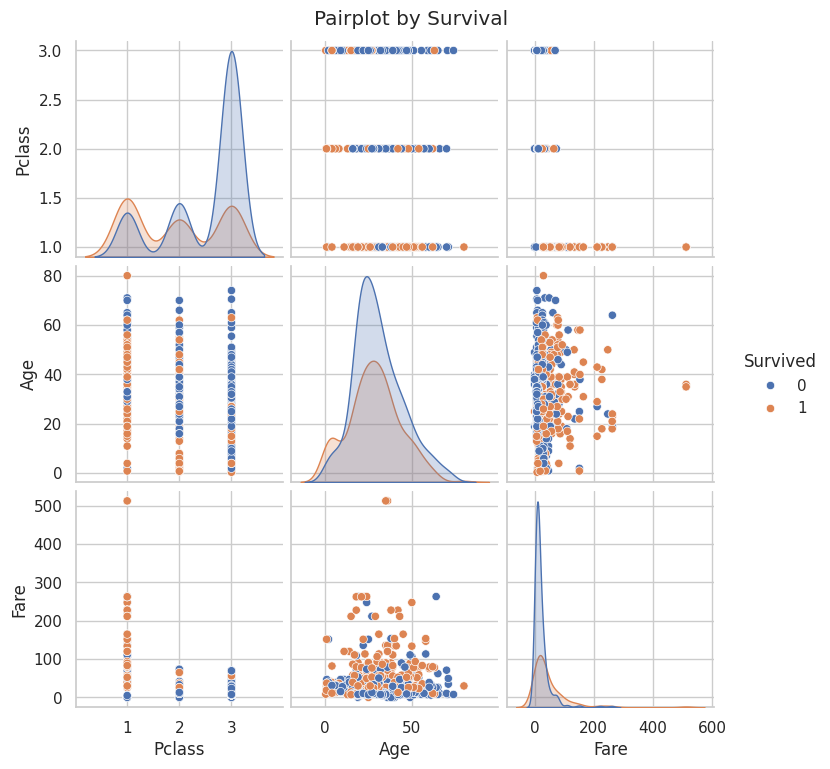

In [7]:
# Pairplot (use subset to avoid clutter)
sns.pairplot(df[['Survived', 'Pclass', 'Age', 'Fare']], hue='Survived')
plt.suptitle('Pairplot by Survival', y=1.02)
plt.show()


### Observation: Pairplot by Survival

- **Age and Fare** show some separation between survivors and non-survivors.
- **Survivors** tend to have **paid higher fares**, which aligns with higher survival rates among 1st class passengers.
- Most of the **non-survivors** were from lower fare and lower class groups.
- There is a wide age range in both survivor and non-survivor groups, but more survivors appear in the **younger to middle-aged range**.
- No strong linear relationships are evident, but class and fare clearly have some influence on survival.

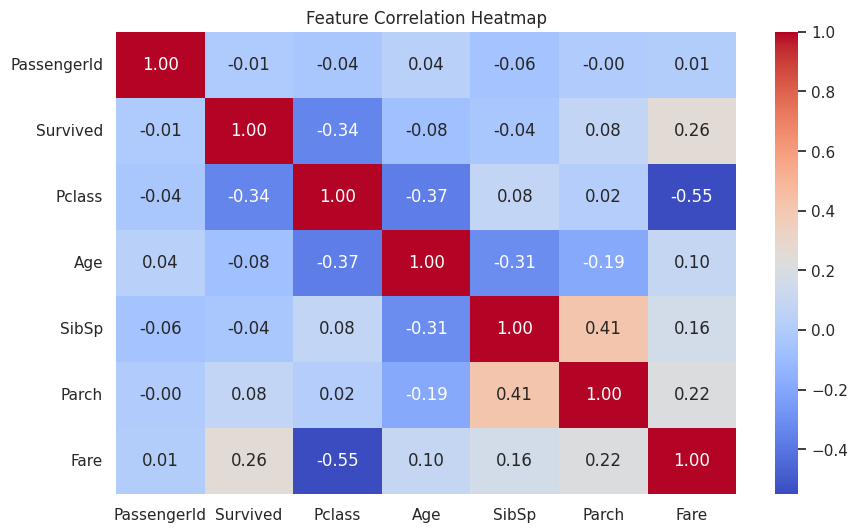

In [8]:
# Correlation heatmap
plt.figure(figsize=(10,6))
# Select only numerical features for correlation calculation
numerical_df = df.select_dtypes(include=['number'])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

### Observation: Feature Correlation
- Survival is positively correlated with Fare and negatively with Pclass.
- SibSp and Parch are moderately correlated — people traveling with family may have had a better survival chance.
- Age and Fare show weak correlation with each other.


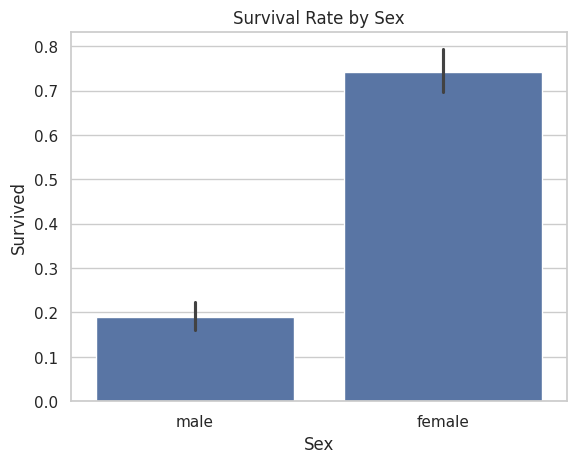

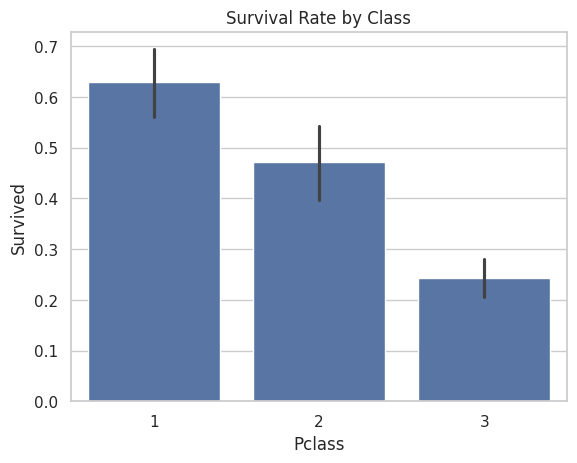

In [9]:
# Survival rate by Sex
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Sex')
plt.show()

# Survival rate by Pclass
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Class')
plt.show()


### Observation: Survival Rate by Sex
- **Females had a much higher survival rate** than males.
- This supports the “women and children first” policy.
- Gender is likely a key feature in predicting survival.


### Observation: Survival Rate by Class

- **1st class passengers** had the **highest survival rate**, followed by 2nd class, with **3rd class having the lowest**.
- This shows a **strong correlation between class and survival** — higher-class passengers had better access to lifeboats or were prioritized during evacuation.



## 📌 Summary of Findings

- **Survival Rate**: Around 38% of passengers survived.
- **Sex**: Females had a significantly higher survival rate than males.
- **Pclass**: 1st class passengers had the highest survival rate.
- **Age**: Younger passengers, especially children, were more likely to survive.
- **Fare**: Higher fares correlated with higher survival—likely due to class/status.
- **SibSp & Parch**: Having family onboard slightly increased survival chances.
- **Missing Data**:
  - `Age`: ~20% missing, needs imputation.
  - `Cabin`: ~77% missing, possibly drop or convert to "has_cabin".
  - `Embarked`: Only 2 missing—can be imputed with the mode.